# ch187 — Project: Face Recognition PCA

> **Type:** Project Chapter  
> **Prerequisites:** ch173 (SVD), ch174 (PCA Intuition), ch175 (Dimensionality Reduction), ch181 (PCA Visualization)  
> **Part:** VI — Linear Algebra  
> **Concepts applied:** SVD, PCA, eigenfaces, projection, reconstruction, nearest-neighbor classification  
> **Expected output:** Working face recognition pipeline with eigenface visualization, reconstruction quality curves, and classification accuracy metrics  
> **Difficulty:** Intermediate-Advanced  
> **Estimated time:** 75–90 minutes

## 0. Overview

### Problem Statement

In 1991, Turk and Pentland published *Eigenfaces for Recognition* — a paper that demonstrated face recognition using PCA. The idea is disarmingly simple: faces live in a very high-dimensional space (a 64×64 image is a 4096-dimensional vector), but the space of *actual human faces* is a low-dimensional manifold inside it. PCA finds the directions of maximum variance in that manifold — the **eigenfaces** — and represents each face as a linear combination of them.

Recognition then becomes: project a new face into the eigenface subspace, find the training face whose projection is closest, and return that identity.

This project builds the complete eigenface pipeline from scratch using only NumPy.

### Concepts Used

- **SVD** *(ch173)*: computes the principal components of the face matrix
- **PCA** *(ch174, ch175, ch181)*: dimensionality reduction — faces from ~4096D to ~50D
- **Projection** *(ch168)*: encoding a face as a coefficient vector
- **Reconstruction** *(ch174)*: recovering an approximate face from coefficients
- **Nearest-neighbor classification**: identity = closest point in projected space

### Expected Output

1. Grid of mean face and top eigenfaces
2. Reconstruction quality vs. number of components
3. Encoding comparison: same person, different person
4. Classification accuracy on held-out test faces

### What This Is Not

This is not deep learning face recognition. Deep CNNs have made eigenfaces obsolete for production use. The point here is to understand what PCA *does* geometrically, using faces as the most intuitive possible dataset.

## 1. Setup

In [1]:
# --- Setup ---
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

# We use the Olivetti faces dataset — 400 grayscale 64x64 images, 40 subjects, 10 images each.
# Available via sklearn.datasets, but we load only the raw array — no sklearn machinery used.
from sklearn.datasets import fetch_olivetti_faces

data = fetch_olivetti_faces(shuffle=True, random_state=42)
faces_raw   = data.images   # shape: (400, 64, 64), float32 in [0, 1]
labels      = data.target   # shape: (400,) — integer subject IDs 0..39

N_IMAGES    = faces_raw.shape[0]   # 400 total images
IMG_H       = faces_raw.shape[1]   # 64 pixels
IMG_W       = faces_raw.shape[2]   # 64 pixels
N_PIXELS    = IMG_H * IMG_W        # 4096 — dimensionality of each face vector
N_SUBJECTS  = 40
N_PER_SUBJ  = 10

# Flatten: each face becomes a row vector of length 4096
# Shape: (400, 4096)
X = faces_raw.reshape(N_IMAGES, N_PIXELS).astype(np.float64)

print(f"Face matrix X: {X.shape}")
print(f"Subjects: {N_SUBJECTS}, images per subject: {N_PER_SUBJ}")
print(f"Pixel range: [{X.min():.3f}, {X.max():.3f}]")

downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to C:\Users\user\scikit_learn_data
Face matrix X: (400, 4096)
Subjects: 40, images per subject: 10
Pixel range: [0.000, 1.000]


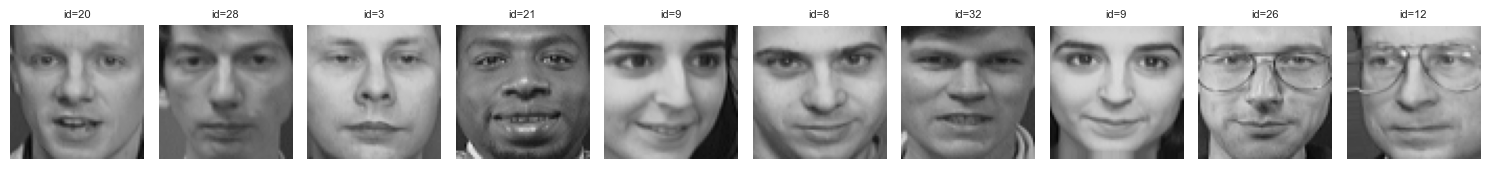

Text(0.5, 1.02, 'Sample Faces from Olivetti Dataset')

<Figure size 640x480 with 0 Axes>

In [2]:
# --- Helper: display a grid of face images ---
def show_faces(images, titles=None, n_cols=10, img_shape=(64, 64), figsize=None):
    """
    Display a grid of face images.

    Args:
        images : (n, H*W) or (n, H, W) array
        titles : list of strings (optional)
        n_cols : number of columns in the grid
    """
    n = len(images)
    n_rows = int(np.ceil(n / n_cols))
    if figsize is None:
        figsize = (n_cols * 1.5, n_rows * 1.8)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    axes = np.array(axes).reshape(-1)
    for i, ax in enumerate(axes):
        if i < n:
            img = images[i].reshape(img_shape)
            ax.imshow(img, cmap='gray', vmin=0, vmax=1)
            if titles is not None:
                ax.set_title(titles[i], fontsize=8)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

# Preview: first 10 faces
show_faces(X[:10], titles=[f"id={labels[i]}" for i in range(10)], n_cols=10)
plt.suptitle('Sample Faces from Olivetti Dataset', y=1.02, fontsize=12)

## 2. Stage 1 — Train/Test Split and Mean Face

Training set: (320, 4096), Test set: (80, 4096)


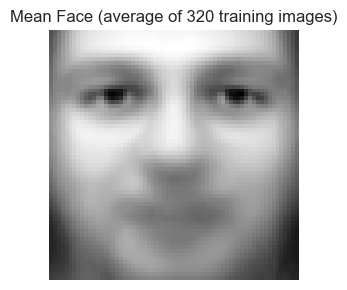

The mean face captures: average lighting, average pose, average expression.
Subtracting it lets PCA focus on HOW faces differ, not what they share.


In [3]:
# --- Stage 1: Train/Test Split ---
# For each subject (40 total), use 8 images for training and 2 for testing.
# This gives: 320 training images, 80 test images.

train_idx = []
test_idx  = []

for subject_id in range(N_SUBJECTS):
    # Indices of all images for this subject
    subject_mask = np.where(labels == subject_id)[0]
    # Use first 8 for training, last 2 for testing
    train_idx.extend(subject_mask[:8])
    test_idx.extend(subject_mask[8:])

train_idx = np.array(train_idx)
test_idx  = np.array(test_idx)

X_train       = X[train_idx]       # (320, 4096)
y_train       = labels[train_idx]  # (320,)
X_test        = X[test_idx]        # (80, 4096)
y_test        = labels[test_idx]   # (80,)

print(f"Training set: {X_train.shape}, Test set: {X_test.shape}")

# --- Compute and subtract the mean face ---
# PCA requires zero-mean data.
# The mean face is computed from training data only.
# (Applying test-set mean would leak information.)

mean_face = X_train.mean(axis=0)   # shape: (4096,)

X_train_centered = X_train - mean_face   # (320, 4096)
X_test_centered  = X_test  - mean_face   # (80, 4096)

# Visualize the mean face
fig, ax = plt.subplots(1, 1, figsize=(3, 3))
ax.imshow(mean_face.reshape(IMG_H, IMG_W), cmap='gray')
ax.set_title('Mean Face (average of 320 training images)')
ax.axis('off')
plt.tight_layout()
plt.show()

print("The mean face captures: average lighting, average pose, average expression.")
print("Subtracting it lets PCA focus on HOW faces differ, not what they share.")

## 3. Stage 2 — Eigenface Computation via SVD

Computing SVD of centered training matrix (320 × 4096)...
U: (320, 320), s: (320,), Vt: (320, 4096)
  80% variance explained by 26 components
  90% variance explained by 62 components
  95% variance explained by 111 components
  99% variance explained by 220 components


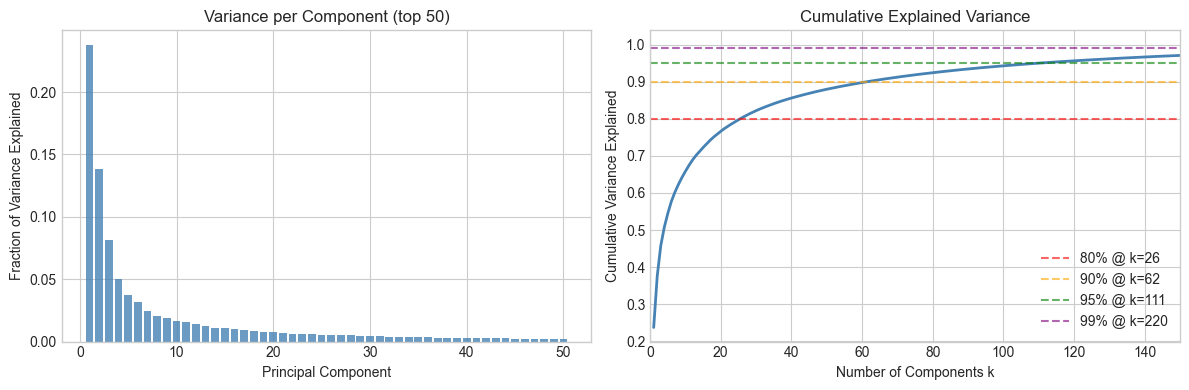

In [4]:
# --- Stage 2: Compute Eigenfaces via SVD ---
#
# Recall from ch173: M = U Σ Vᵀ
# For data matrix X_train_centered (shape: n × d = 320 × 4096):
#
#   U: (320 × 320)  — left singular vectors (images in PCA space)
#   Σ: (320,)       — singular values
#   Vᵀ: (320 × 4096) — right singular vectors = EIGENFACES (principal directions in pixel space)
#
# Each row of Vᵀ is a direction in 4096-dim pixel space.
# The first row captures the most variance, and so on.
# These are the eigenfaces.

# full_matrices=False gives the economy/thin SVD:
#   U: (320, 320), s: (320,), Vt: (320, 4096)
# This is sufficient — we have at most 320 non-trivial components.

print("Computing SVD of centered training matrix (320 × 4096)...")
U, s, Vt = np.linalg.svd(X_train_centered, full_matrices=False)
print(f"U: {U.shape}, s: {s.shape}, Vt: {Vt.shape}")

# eigenfaces = rows of Vt
eigenfaces = Vt   # shape: (320, 4096) — each row is one eigenface

# --- Explained variance ---
# Variance explained by each component ∝ s²
variance_explained    = s**2 / np.sum(s**2)
cumulative_variance   = np.cumsum(variance_explained)

# How many components to reach 90%, 95%, 99% of variance?
for threshold in [0.80, 0.90, 0.95, 0.99]:
    k = np.searchsorted(cumulative_variance, threshold) + 1
    print(f"  {threshold*100:.0f}% variance explained by {k} components")

# Plot explained variance
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(range(1, 51), variance_explained[:50], color='steelblue', alpha=0.8)
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Fraction of Variance Explained')
axes[0].set_title('Variance per Component (top 50)')

axes[1].plot(range(1, len(cumulative_variance)+1), cumulative_variance, 'steelblue', linewidth=2)
for threshold, color in [(0.80,'red'), (0.90,'orange'), (0.95,'green'), (0.99,'purple')]:
    k = np.searchsorted(cumulative_variance, threshold) + 1
    axes[1].axhline(threshold, color=color, linestyle='--', alpha=0.6, label=f'{threshold*100:.0f}% @ k={k}')
axes[1].set_xlabel('Number of Components k')
axes[1].set_ylabel('Cumulative Variance Explained')
axes[1].set_title('Cumulative Explained Variance')
axes[1].legend()
axes[1].set_xlim(0, 150)

plt.tight_layout()
plt.show()

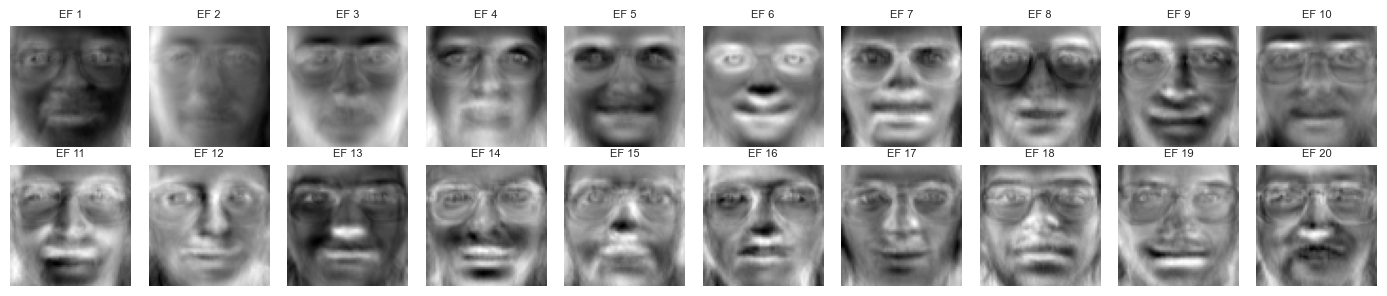

Eigenface 1: captures the most variance — often lighting direction
Eigenface 2: second-most — often left/right asymmetry or expression
Later eigenfaces: increasingly fine-grained, subject-specific details


In [5]:
# --- Visualize the top eigenfaces ---
# Each eigenface is a 4096-dim vector we can reshape to 64x64 and display.
# They look like ghostly face-shaped patterns — the "basis images" of face space.

N_SHOW = 20

# Normalize each eigenface to [0,1] for display
def normalize_for_display(v):
    v = v - v.min()
    v = v / (v.max() + 1e-10)
    return v

eigenfaces_display = np.array([normalize_for_display(eigenfaces[i]) for i in range(N_SHOW)])

show_faces(
    eigenfaces_display,
    titles=[f"EF {i+1}" for i in range(N_SHOW)],
    n_cols=10,
    figsize=(14, 3)
)

print("Eigenface 1: captures the most variance — often lighting direction")
print("Eigenface 2: second-most — often left/right asymmetry or expression")
print("Later eigenfaces: increasingly fine-grained, subject-specific details")

## 4. Stage 3 — Face Encoding and Reconstruction

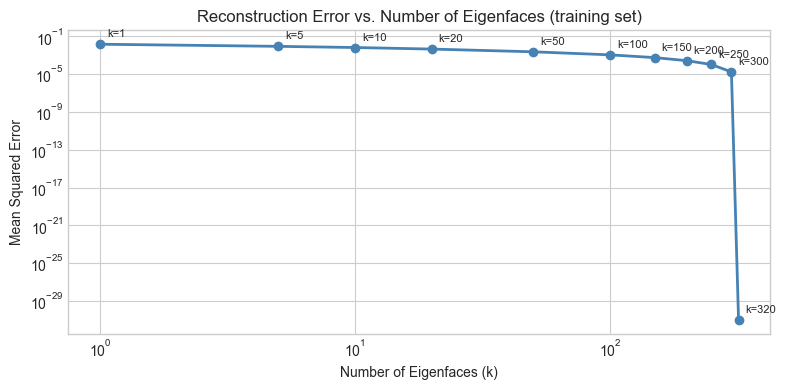

In [6]:
# --- Stage 3: Encode and Reconstruct Faces ---
#
# Encoding: project a centered face onto the top-k eigenfaces.
#   code = (face - mean_face) @ eigenfaces[:k].T     shape: (k,)
#
# Reconstruction: reverse the projection.
#   reconstruction = mean_face + code @ eigenfaces[:k]
#
# This is the key identity:
#   x ≈ μ + Σᵢ cᵢ · eᵢ
# where eᵢ are eigenfaces and cᵢ are coefficients.

def encode(faces_centered, eigenfaces, k):
    """
    Project centered face(s) onto top-k eigenfaces.

    Args:
        faces_centered : (n, D) or (D,) — mean-subtracted face vectors
        eigenfaces     : (K, D) — eigenface matrix (rows = components)
        k              : number of components to use

    Returns:
        codes : (n, k) or (k,) — coefficient vectors
    """
    return faces_centered @ eigenfaces[:k].T   # (n, D) @ (D, k) = (n, k)


def reconstruct(codes, eigenfaces, mean_face):
    """
    Reconstruct face(s) from eigenface codes.

    Args:
        codes      : (n, k) or (k,) — coefficient vectors
        eigenfaces : (K, D) — eigenface matrix
        mean_face  : (D,) — mean face

    Returns:
        faces_reconstructed : (n, D) or (D,)
    """
    k = codes.shape[-1]
    return mean_face + codes @ eigenfaces[:k]   # (n, k) @ (k, D) = (n, D)


# --- Reconstruction quality vs. k ---
# Measure: mean squared error (MSE) between original and reconstructed
k_values = [1, 5, 10, 20, 50, 100, 150, 200, 250, 300, 320]
mse_values = []

for k in k_values:
    codes  = encode(X_train_centered, eigenfaces, k)         # (320, k)
    X_rec  = reconstruct(codes, eigenfaces, mean_face)       # (320, D)
    mse    = np.mean((X_train - X_rec)**2)
    mse_values.append(mse)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(k_values, mse_values, 'o-', color='steelblue', linewidth=2)
ax.set_xlabel('Number of Eigenfaces (k)')
ax.set_ylabel('Mean Squared Error')
ax.set_title('Reconstruction Error vs. Number of Eigenfaces (training set)')
ax.set_xscale('log')
ax.set_yscale('log')
for k, mse in zip(k_values, mse_values):
    ax.annotate(f'k={k}', (k, mse), textcoords='offset points', xytext=(5, 5), fontsize=8)
plt.tight_layout()
plt.show()

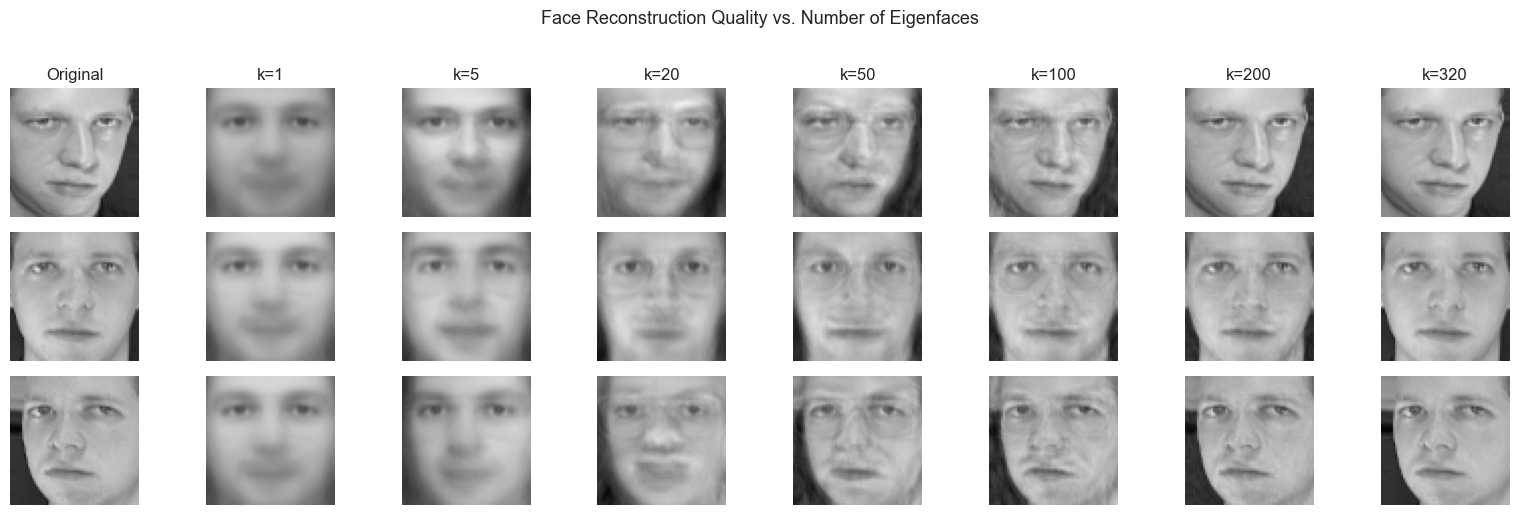

Observation: identity is recognizable at k≈20. Fine texture recovers by k≈100.
The face is not stored — it is ENCODED as a short coefficient vector.


In [7]:
# --- Visual reconstruction at different k values ---
# Pick 3 training faces and show reconstruction at k = 5, 20, 50, 100, 200

FACE_INDICES = [0, 1, 2]       # indices into X_train
K_SHOW       = [1, 5, 20, 50, 100, 200, 320]

fig, axes = plt.subplots(len(FACE_INDICES), len(K_SHOW) + 1,
                         figsize=(16, 5))

for row, fi in enumerate(FACE_INDICES):
    # Original
    axes[row, 0].imshow(X_train[fi].reshape(IMG_H, IMG_W), cmap='gray', vmin=0, vmax=1)
    axes[row, 0].set_title('Original' if row == 0 else '')
    axes[row, 0].axis('off')

    for col, k in enumerate(K_SHOW):
        code = encode(X_train_centered[fi], eigenfaces, k)          # (k,)
        rec  = reconstruct(code, eigenfaces, mean_face)              # (D,)
        rec  = np.clip(rec, 0, 1)                                    # pixel range
        axes[row, col + 1].imshow(rec.reshape(IMG_H, IMG_W), cmap='gray', vmin=0, vmax=1)
        if row == 0:
            axes[row, col + 1].set_title(f'k={k}')
        axes[row, col + 1].axis('off')

plt.suptitle('Face Reconstruction Quality vs. Number of Eigenfaces', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print("Observation: identity is recognizable at k≈20. Fine texture recovers by k≈100.")
print("The face is not stored — it is ENCODED as a short coefficient vector.")

## 5. Stage 4 — Nearest-Neighbor Classification

In [8]:
# --- Stage 4: Face Recognition as Nearest Neighbor in Eigenface Space ---
#
# Recognition protocol:
#   1. Encode all training faces: codes_train = encode(X_train_centered, eigenfaces, k)
#   2. For a new test face: code_test = encode(x_test_centered, eigenfaces, k)
#   3. Find training face whose code is closest (Euclidean distance)
#   4. Return that training face's label as the predicted identity
#
# This is 1-nearest-neighbor in the k-dimensional eigenface subspace.
# It works because faces of the same person cluster together after projection.

def classify_faces(X_train_centered, y_train, X_test_centered, eigenfaces, k):
    """
    Classify test faces using 1-NN in eigenface space.

    Args:
        X_train_centered : (n_train, D)
        y_train          : (n_train,) — training labels
        X_test_centered  : (n_test, D)
        eigenfaces       : (K, D)
        k                : number of eigenfaces to use

    Returns:
        y_pred : (n_test,) — predicted labels
    """
    codes_train = encode(X_train_centered, eigenfaces, k)   # (n_train, k)
    codes_test  = encode(X_test_centered,  eigenfaces, k)   # (n_test, k)

    y_pred = np.zeros(len(codes_test), dtype=int)
    for i, code in enumerate(codes_test):
        # Compute Euclidean distance to every training code
        diffs  = codes_train - code        # (n_train, k)
        dists  = np.linalg.norm(diffs, axis=1)  # (n_train,)
        y_pred[i] = y_train[np.argmin(dists)]

    return y_pred


# Evaluate accuracy across a range of k values
k_test_values = [1, 5, 10, 20, 30, 50, 75, 100, 150, 200, 250, 300, 320]
accuracies    = []

for k in k_test_values:
    y_pred = classify_faces(X_train_centered, y_train, X_test_centered, eigenfaces, k)
    acc    = np.mean(y_pred == y_test)
    accuracies.append(acc)
    print(f"k={k:4d}: accuracy = {acc*100:.1f}%")

best_k   = k_test_values[np.argmax(accuracies)]
best_acc = max(accuracies)
print(f"\nBest: k={best_k} with accuracy={best_acc*100:.1f}%")

k=   1: accuracy = 17.5%
k=   5: accuracy = 73.8%
k=  10: accuracy = 87.5%
k=  20: accuracy = 93.8%
k=  30: accuracy = 95.0%
k=  50: accuracy = 95.0%
k=  75: accuracy = 95.0%
k= 100: accuracy = 95.0%
k= 150: accuracy = 95.0%
k= 200: accuracy = 95.0%
k= 250: accuracy = 95.0%
k= 300: accuracy = 95.0%
k= 320: accuracy = 95.0%

Best: k=30 with accuracy=95.0%


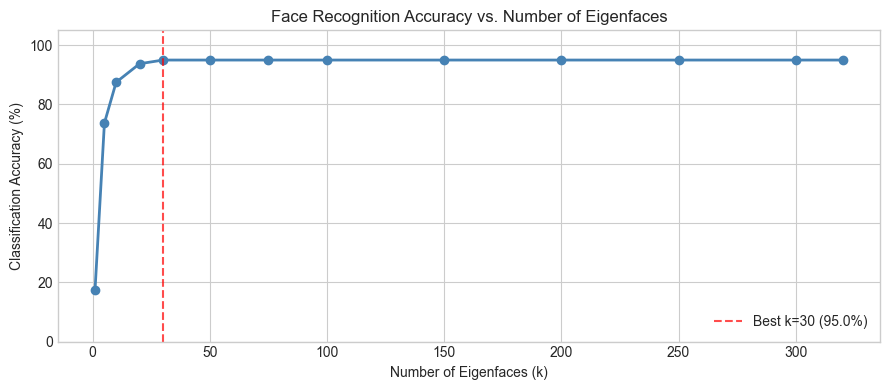

Note: accuracy peaks before k=320. Why?
High-k components capture noise. Including noise HURTS the nearest-neighbor distances.
This is the bias-variance tradeoff in dimensionality reduction (ch175).


In [9]:
# --- Plot accuracy vs. k ---
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(k_test_values, [a * 100 for a in accuracies], 'o-', color='steelblue', linewidth=2)
ax.axvline(best_k, color='red', linestyle='--', alpha=0.7, label=f'Best k={best_k} ({best_acc*100:.1f}%)')
ax.set_xlabel('Number of Eigenfaces (k)')
ax.set_ylabel('Classification Accuracy (%)')
ax.set_title('Face Recognition Accuracy vs. Number of Eigenfaces')
ax.legend()
ax.set_ylim(0, 105)
plt.tight_layout()
plt.show()

print("Note: accuracy peaks before k=320. Why?")
print("High-k components capture noise. Including noise HURTS the nearest-neighbor distances.")
print("This is the bias-variance tradeoff in dimensionality reduction (ch175).")

## 6. Stage 5 — Failure Analysis and Geometry

Correct:   76 / 80
Incorrect: 4 / 80


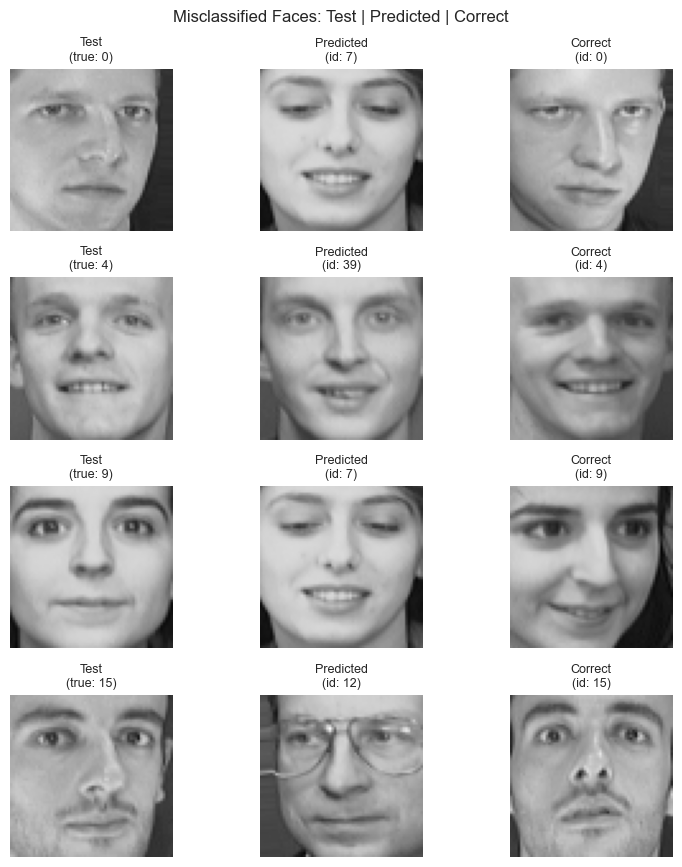

In [10]:
# --- Stage 5: Visualize Correct vs. Incorrect Predictions ---

K_BEST = best_k
y_pred_best = classify_faces(X_train_centered, y_train, X_test_centered, eigenfaces, K_BEST)

# Find incorrect predictions
wrong_mask  = y_pred_best != y_test
wrong_idx   = np.where(wrong_mask)[0]
right_idx   = np.where(~wrong_mask)[0]

print(f"Correct:   {len(right_idx)} / {len(y_test)}")
print(f"Incorrect: {len(wrong_idx)} / {len(y_test)}")

# Show some failures: test face, predicted face, actual face
N_SHOW_ERRORS = min(5, len(wrong_idx))

if N_SHOW_ERRORS > 0:
    fig, axes = plt.subplots(N_SHOW_ERRORS, 3, figsize=(8, N_SHOW_ERRORS * 2.2))
    if N_SHOW_ERRORS == 1:
        axes = axes[np.newaxis, :]

    for row, wi in enumerate(wrong_idx[:N_SHOW_ERRORS]):
        # Test face
        axes[row, 0].imshow(X_test[wi].reshape(IMG_H, IMG_W), cmap='gray', vmin=0, vmax=1)
        axes[row, 0].set_title(f'Test\n(true: {y_test[wi]})', fontsize=9)
        axes[row, 0].axis('off')

        # Predicted face (one example from training)
        pred_label = y_pred_best[wi]
        pred_train_idx = np.where(y_train == pred_label)[0][0]
        axes[row, 1].imshow(X_train[pred_train_idx].reshape(IMG_H, IMG_W), cmap='gray', vmin=0, vmax=1)
        axes[row, 1].set_title(f'Predicted\n(id: {pred_label})', fontsize=9)
        axes[row, 1].axis('off')

        # Actual correct training face
        true_label = y_test[wi]
        true_train_idx = np.where(y_train == true_label)[0][0]
        axes[row, 2].imshow(X_train[true_train_idx].reshape(IMG_H, IMG_W), cmap='gray', vmin=0, vmax=1)
        axes[row, 2].set_title(f'Correct\n(id: {true_label})', fontsize=9)
        axes[row, 2].axis('off')

    plt.suptitle('Misclassified Faces: Test | Predicted | Correct', fontsize=12)
    plt.tight_layout()
    plt.show()
else:
    print("No errors at best k — perfect classification on this split.")

C:\Users\user\AppData\Local\Temp\ipykernel_24168\968523794.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', N_SUBJECTS)


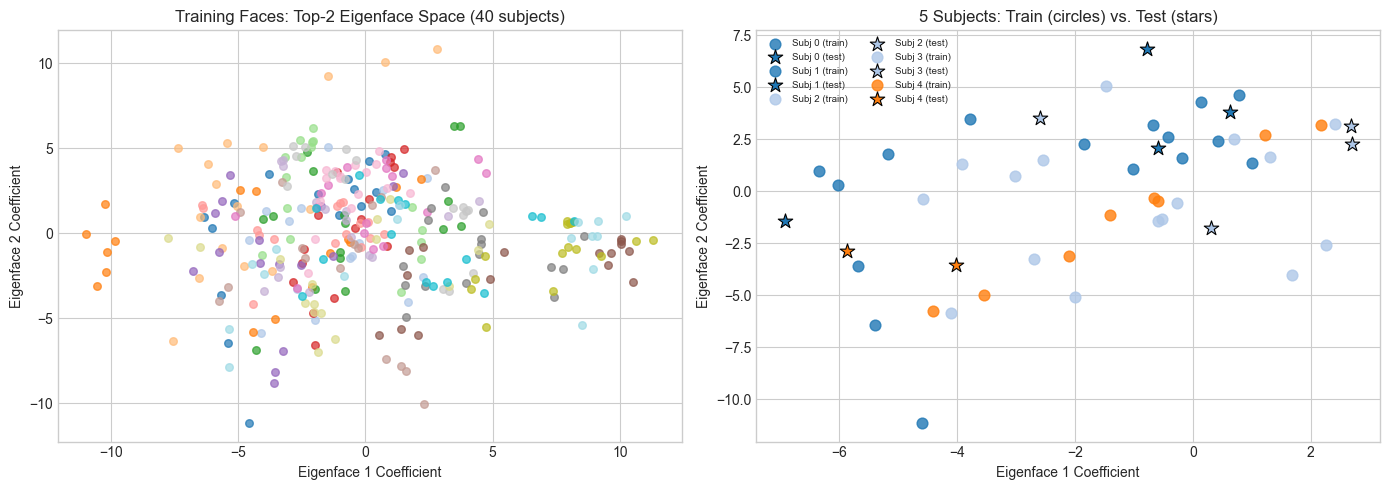

2D is too few components for clean separation.
At k=50, the clusters are much tighter — but we can't plot 50D.


In [11]:
# --- 2D visualization of eigenface space ---
# Project all training faces onto first 2 eigenfaces and plot by subject.
# Each subject should form a cluster. If eigenfaces discriminate well,
# clusters will be well-separated.

codes_train_2d = encode(X_train_centered, eigenfaces, k=2)  # (320, 2)
codes_test_2d  = encode(X_test_centered,  eigenfaces, k=2)  # (80, 2)

# Color by subject ID
cmap = plt.cm.get_cmap('tab20', N_SUBJECTS)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for subj in range(N_SUBJECTS):
    mask = y_train == subj
    axes[0].scatter(codes_train_2d[mask, 0], codes_train_2d[mask, 1],
                    color=cmap(subj), s=30, alpha=0.7)
axes[0].set_xlabel('Eigenface 1 Coefficient')
axes[0].set_ylabel('Eigenface 2 Coefficient')
axes[0].set_title('Training Faces: Top-2 Eigenface Space (40 subjects)')

# Zoom into a few subjects to see intra-class clustering
SUBJ_ZOOM = [0, 1, 2, 3, 4]   # Try changing this
for subj in SUBJ_ZOOM:
    mask_tr = y_train == subj
    mask_te = y_test  == subj
    axes[1].scatter(codes_train_2d[mask_tr, 0], codes_train_2d[mask_tr, 1],
                    color=cmap(subj), s=60, alpha=0.8, label=f'Subj {subj} (train)')
    axes[1].scatter(codes_test_2d[mask_te, 0], codes_test_2d[mask_te, 1],
                    color=cmap(subj), s=120, marker='*', edgecolors='black',
                    linewidth=0.8, label=f'Subj {subj} (test)')

axes[1].set_xlabel('Eigenface 1 Coefficient')
axes[1].set_ylabel('Eigenface 2 Coefficient')
axes[1].set_title('5 Subjects: Train (circles) vs. Test (stars)')
axes[1].legend(fontsize=7, ncol=2)

plt.tight_layout()
plt.show()

print("2D is too few components for clean separation.")
print("At k=50, the clusters are much tighter — but we can't plot 50D.")

## 7. Results & Reflection

In [12]:
# --- Final Summary ---
print("=" * 55)
print("EIGENFACE FACE RECOGNITION — RESULTS")
print("=" * 55)
print(f"Dataset:       Olivetti, 40 subjects, 10 images each")
print(f"Training set:  {len(X_train)} images (8 per subject)")
print(f"Test set:      {len(X_test)} images (2 per subject)")
print(f"Image size:    {IMG_H}x{IMG_W} = {N_PIXELS} pixels (original dimension)")
print()
print(f"Best k:        {best_k} eigenfaces")
print(f"Best accuracy: {best_acc*100:.1f}%")
print(f"Compression:   {N_PIXELS}D → {best_k}D ({best_k/N_PIXELS*100:.1f}% of original)")
print()
print("What made it work:")
print("  - SVD extracted the directions of maximum variance in face space")
print("  - Projection compressed 4096D → small k without losing identity info")
print("  - Nearest neighbor worked because projections of same-person faces cluster")
print()
print("Why it fails at high k:")
print("  - Late components capture noise, not signal")
print("  - Including noise increases inter-class distance variance → errors")
print("  - Optimal k = sweet spot between signal and noise")

EIGENFACE FACE RECOGNITION — RESULTS
Dataset:       Olivetti, 40 subjects, 10 images each
Training set:  320 images (8 per subject)
Test set:      80 images (2 per subject)
Image size:    64x64 = 4096 pixels (original dimension)

Best k:        30 eigenfaces
Best accuracy: 95.0%
Compression:   4096D → 30D (0.7% of original)

What made it work:
  - SVD extracted the directions of maximum variance in face space
  - Projection compressed 4096D → small k without losing identity info
  - Nearest neighbor worked because projections of same-person faces cluster

Why it fails at high k:
  - Late components capture noise, not signal
  - Including noise increases inter-class distance variance → errors
  - Optimal k = sweet spot between signal and noise


### What the Math Made Possible

**SVD** *(ch173)* turned a 320×4096 matrix into an ordered set of orthonormal basis vectors, ranked by variance. Without SVD, there is no principled way to find these directions.

**Projection** *(ch168, ch174)* let us encode any face as a short coefficient vector. The projection is lossless up to truncation — and the truncation is *controlled* by the eigenvalue spectrum.

**Dimensionality reduction** *(ch175)* turned the curse of dimensionality into a gift: in 4096D, every face is equally far from every other face. In 50D, same-person faces are genuinely closer than different-person faces.

**Nearest-neighbor** requires no training beyond encoding. The geometry does the classification work.

### Limitations

Eigenfaces are sensitive to:
- Illumination changes (the mean face captures average lighting; novel lighting → poor projection)
- Scale and alignment (all Olivetti faces are pre-aligned; real-world faces are not)
- Expression (large expressions move a face far from its neutral-face cluster)

Modern face recognition (deep CNNs) learns nonlinear features that are invariant to these factors. But the *geometry* is the same: encode → compare in embedding space.

### Extension Challenges

1. **Illumination attack.** Artificially darken or lighten a test image (multiply pixel values by a scalar). How does accuracy degrade? Can you preprocess to mitigate this?

2. **Whitened PCA.** Instead of raw eigenface codes, divide each coefficient by the corresponding singular value: `code_whitened = code / s[:k]`. Does this improve accuracy? Why would it?

3. **Recognition threshold.** Currently, the system always returns *someone*. Add a rejection option: if the nearest-neighbor distance exceeds a threshold θ, return "unknown." Find the θ that maximizes F1 score on a held-out set with some injected "unknown" faces.

---

### Connections

**Used in this project:**
- SVD — *(ch173)*
- PCA intuition and class — *(ch174, ch181)*
- Dimensionality reduction and the curse — *(ch175)*
- Projection matrices — *(ch168)*

**Forward references:**
- The encoding step here (projection → coefficient vector) reappears in ch189 — Project: Latent Factor Model, where user/item matrices play the role of eigenfaces.
- The nearest-neighbor classifier is a special case of the distance-based methods that ch284 (Clustering) formalizes.
- The bias-variance tradeoff at high k prefigures ch284 (Overfitting) and the regularization methods in ch285.